In [6]:
import sys, os

# Add the 'src' folder to the Python path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../../..', 'src')))

from eda.eda_util import load_data



🎯 SECTION 4: TARGET VARIABLE ANALYSIS
--------------------------------------------------
Analyzing target variable: 'Reviewer_Score'

📊 Reviewer_Score Statistics:


,count,mean,std,min,25%,50%,75%,max
Reviewer_Score,515738.0,8.395077,1.637856,2.5,7.5,8.8,9.6,10.0


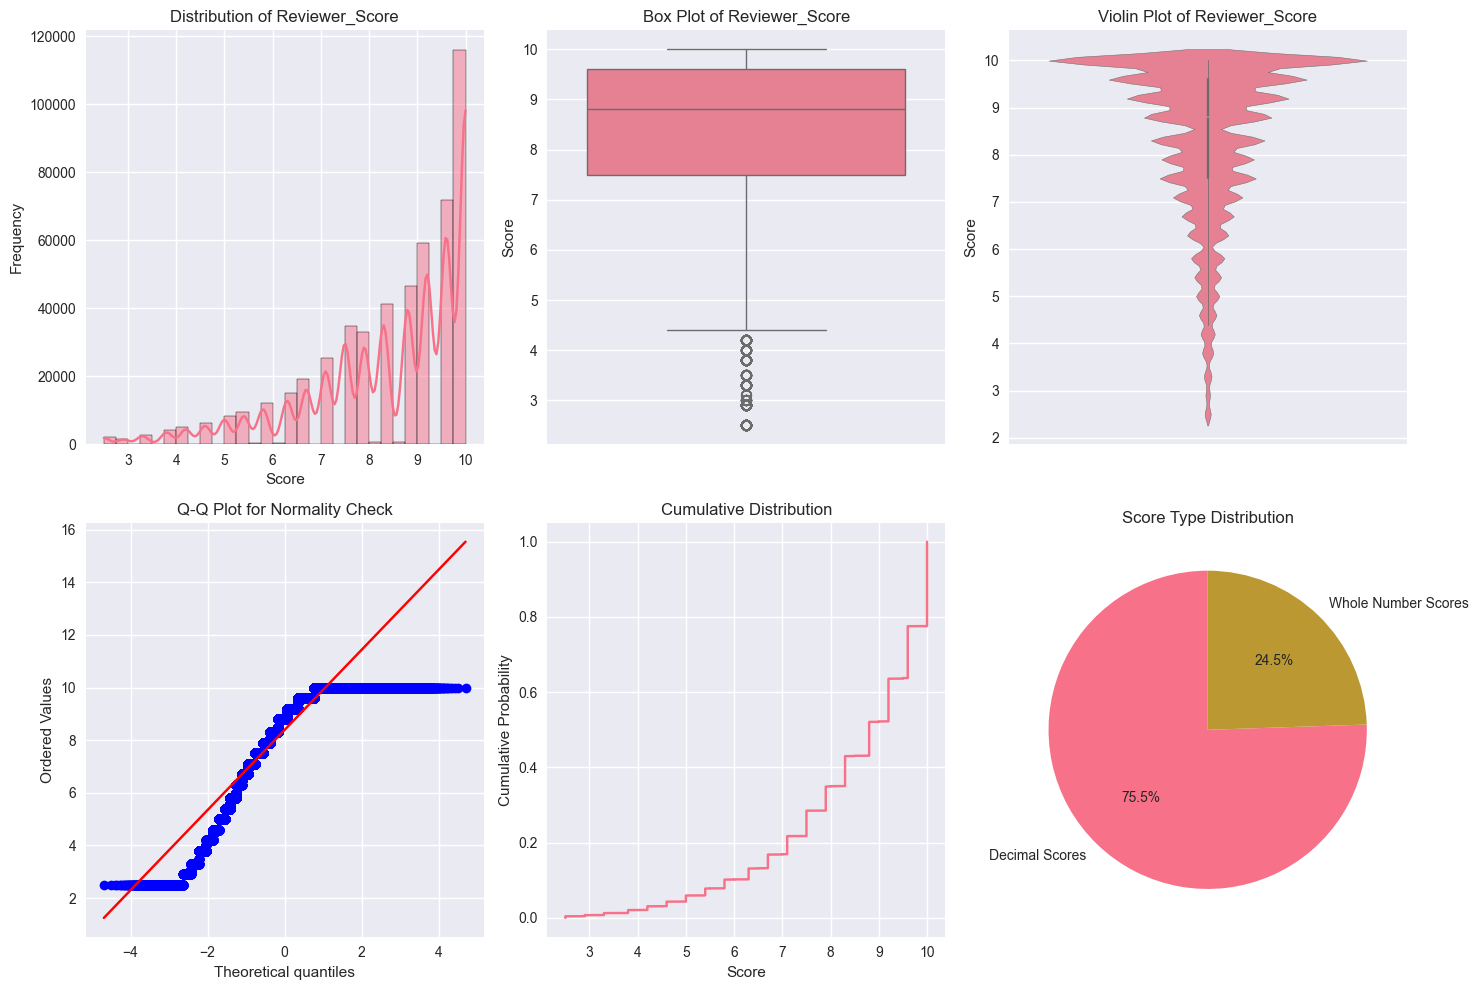


💡 Reviewer_Score INSIGHTS:
• Range: 2.5 to 10.0
• Mean: 8.40
• Median: 8.80
• Standard Deviation: 1.64
• Skewness: -1.19 (Moderately skewed)
• Potential outliers (IQR method): 15907 (3.08%)


: 

In [ ]:
# SECTION 4: TARGET VARIABLE ANALYSIS
# ===================================

print("\n\n🎯 SECTION 4: TARGET VARIABLE ANALYSIS")
print("-" * 50)

# Assuming 'Reviewer_Score' is the target variable
target_column = 'Reviewer_Score'

if target_column in df.columns:
    print(f"Analyzing target variable: '{target_column}'")
    
    # 4.1 Basic Statistics
    target_stats = df[target_column].describe()
    print(f"\n📊 {target_column} Statistics:")
    display(pd.DataFrame(target_stats).T)
    
    # 4.2 Distribution Visualization
    plt.figure(figsize=(15, 10))
    
    # Histogram with KDE
    plt.subplot(2, 3, 1)
    sns.histplot(df[target_column], kde=True, bins=30)
    plt.title(f'Distribution of {target_column}')
    plt.xlabel('Score')
    plt.ylabel('Frequency')
    
    # Box plot
    plt.subplot(2, 3, 2)
    sns.boxplot(y=df[target_column])
    plt.title(f'Box Plot of {target_column}')
    plt.ylabel('Score')
    
    # Violin plot
    plt.subplot(2, 3, 3)
    sns.violinplot(y=df[target_column])
    plt.title(f'Violin Plot of {target_column}')
    plt.ylabel('Score')
    
    # Q-Q plot for normality check
    plt.subplot(2, 3, 4)
    from scipy import stats
    stats.probplot(df[target_column].dropna(), dist="norm", plot=plt)
    plt.title('Q-Q Plot for Normality Check')
    
    # Cumulative distribution
    plt.subplot(2, 3, 5)
    sorted_scores = np.sort(df[target_column].dropna())
    y_vals = np.arange(len(sorted_scores)) / float(len(sorted_scores))
    plt.plot(sorted_scores, y_vals)
    plt.title('Cumulative Distribution')
    plt.xlabel('Score')
    plt.ylabel('Cumulative Probability')
    
    # Score type analysis (whole vs decimal)
    plt.subplot(2, 3, 6)
    score_types = (df[target_column] % 1 == 0).value_counts()
    labels = ['Decimal Scores', 'Whole Number Scores']
    plt.pie(score_types.values, labels=labels, autopct='%1.1f%%', startangle=90)
    plt.title('Score Type Distribution')
    
    plt.tight_layout()
    plt.show()
    
    # 4.3 Target Variable Insights
    print(f"\n💡 {target_column} INSIGHTS:")
    print(f"• Range: {df[target_column].min():.1f} to {df[target_column].max():.1f}")
    print(f"• Mean: {df[target_column].mean():.2f}")
    print(f"• Median: {df[target_column].median():.2f}")
    print(f"• Standard Deviation: {df[target_column].std():.2f}")
    print(f"• Skewness: {df[target_column].skew():.2f} ({'Moderately' if abs(df[target_column].skew()) > 0.5 else 'Slightly'} skewed)")
    
    # Check for potential outliers using IQR
    Q1 = df[target_column].quantile(0.25)
    Q3 = df[target_column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[target_column] < lower_bound) | (df[target_column] > upper_bound)]
    print(f"• Potential outliers (IQR method): {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
    
else:
    print(f"❌ Target column '{target_column}' not found in dataset!")
    print("Available columns:", list(df.columns))